In [3]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost matplotlib seaborn pandas

In [1]:
import pandas as pd
import requests

# URL da API para os dados KOI
API_URL_KOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+cumulative&format=json"

print("🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_koi = requests.get(API_URL_KOI)
    response_koi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados KOI recebidos! Convertendo para DataFrame...")
    data_koi = response_koi.json()
    df_koi = pd.DataFrame(data_koi)

    print(f"🎉 Sucesso! DataFrame 'df_koi' criado com {df_koi.shape[0]} linhas.")
    
except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados KOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_koi.head())

🚀 Buscando dados da API da NASA (Kepler Objects of Interest)...
✅ Dados KOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_koi' criado com 9564 linhas.


Carrega dados do TOI

In [2]:
import pandas as pd
import requests

# URL da API para os dados TOI
API_URL_TOI = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+toi&format=json"

print("🚀 Buscando dados da API da NASA (TESS Objects of Interest)...")

try:
    # Faz a requisição para a API
    response_toi = requests.get(API_URL_TOI)
    response_toi.raise_for_status() # Verifica se a requisição foi bem-sucedida

    # Converte a resposta JSON em um DataFrame
    print("✅ Dados TOI recebidos! Convertendo para DataFrame...")
    data_toi = response_toi.json()
    df_toi = pd.DataFrame(data_toi)

    print(f"🎉 Sucesso! DataFrame 'df_toi' criado com {df_toi.shape[0]} linhas.")

except requests.exceptions.RequestException as e:
    print(f"❌ Erro ao buscar dados TOI: {e}")

# Verificando as primeiras linhas (opcional)
# print(df_toi.head())

🚀 Buscando dados da API da NASA (TESS Objects of Interest)...
✅ Dados TOI recebidos! Convertendo para DataFrame...
🎉 Sucesso! DataFrame 'df_toi' criado com 7703 linhas.


Unificando os Dados KOI e TOI para o Modelo

In [17]:
import pandas as pd
import numpy as np

# Supondo que df_koi e df_toi já foram carregados

# --- 1. Mapeamento CORRIGIDO ---
print("⚙️  Processando dados com mapeamento robusto...")

# Mapeamento para KOI (completo)
map_koi = {
    'koi_disposition': 'target_disposition',
    'koi_period': 'orbital_period',
    'koi_duration': 'transit_duration_hr',
    'koi_depth': 'transit_depth_ppm',
    'koi_prad': 'planet_radius_earth',
    'koi_steff': 'stellar_temp_k',
    'koi_srad': 'stellar_radius_solar',
    'koi_smass': 'stellar_mass_solar',
    'koi_impact': 'impact_parameter',
    'koi_teq': 'equilibrium_temp'
}
df_koi_std = df_koi[list(map_koi.keys())].rename(columns=map_koi)
target_map_koi = {'CONFIRMED': 1, 'CANDIDATE': 1, 'FALSE POSITIVE': 0}
df_koi_std['target'] = df_koi_std['target_disposition'].map(target_map_koi)
df_koi_std['source'] = 'Kepler'

# Mapeamento para TOI (apenas colunas que existem)
map_toi = {
    'tfopwg_disp': 'target_disposition',
    'pl_orbper': 'orbital_period',
    'pl_trandurh': 'transit_duration_hr',
    'pl_trandep': 'transit_depth_ppm',
    'pl_rade': 'planet_radius_earth',
    'st_teff': 'stellar_temp_k',
    'st_rad': 'stellar_radius_solar',
    # 'st_mass' e 'pl_imppar' foram removidos pois não existem na API 'toi'
    'pl_eqt': 'equilibrium_temp'
}
df_toi_std = df_toi[list(map_toi.keys())].rename(columns=map_toi)
target_map_toi = {'KP': 1, 'CP': 1, 'FP': 0}
df_toi_std['target'] = df_toi_std['target_disposition'].map(target_map_toi)
df_toi_std['source'] = 'TESS'

# --- 2. Combinar e Limpar ---
print("🤝 Combinando os dois DataFrames...")
# O pd.concat vai automaticamente criar as colunas faltantes no df_toi_std e preencher com NaN
df_combined = pd.concat([df_koi_std, df_toi_std], ignore_index=True)
df_combined.dropna(subset=['target'], inplace=True)
df_combined['target'] = df_combined['target'].astype(int)
df_combined.drop(columns=['target_disposition'], inplace=True)

# --- 3. Engenharia de Features ---
print("🛠️  Iniciando a Engenharia de Features...")
df_featured = df_combined.copy()

# A densidade estelar será calculada. Onde a massa for NaN (dados TESS), o resultado será NaN.
df_featured['stellar_density'] = df_featured['stellar_mass_solar'] / (df_featured['stellar_radius_solar']**3 + 1e-6)
df_featured['duration_over_period'] = df_featured['transit_duration_hr'] / (df_featured['orbital_period'] * 24 + 1e-6)
df_featured['depth_per_planet_radius'] = df_featured['transit_depth_ppm'] / (df_featured['planet_radius_earth']**2 + 1e-6)

# Substitui possíveis valores infinitos (resultantes de divisão por zero) por 0
df_featured.replace([np.inf, -np.inf], 0, inplace=True)

print("✅ Processo de preparação e feature engineering concluído sem erros.")
print("Verificando colunas que ficaram com valores nulos para os dados TESS:")
# Mostra quantos valores nulos temos nas colunas que não existiam no TESS
print(df_featured[df_featured['source'] == 'TESS'][['stellar_mass_solar', 'impact_parameter']].isnull().sum())

⚙️  Processando dados com mapeamento robusto...
🤝 Combinando os dois DataFrames...
🛠️  Iniciando a Engenharia de Features...
✅ Processo de preparação e feature engineering concluído sem erros.
Verificando colunas que ficaram com valores nulos para os dados TESS:
stellar_mass_solar    2464
impact_parameter      2464
dtype: int64


Treinando e Avaliando o Modelo XGBoost

🚀 Iniciando o processo de treinamento e avaliação...
Dados divididos: 8419 para treino, 3609 para teste.
💪 Treinando o modelo... Isso pode levar alguns segundos.
✅ Modelo treinado com sucesso!

--- Resultados da Avaliação no Conjunto de Teste ---
Acurácia: 0.8318

Relatório de Classificação:
                    precision    recall  f1-score   support

Falso Positivo (0)       0.84      0.82      0.83      1811
       Planeta (1)       0.83      0.84      0.83      1798

          accuracy                           0.83      3609
         macro avg       0.83      0.83      0.83      3609
      weighted avg       0.83      0.83      0.83      3609


Matriz de Confusão:


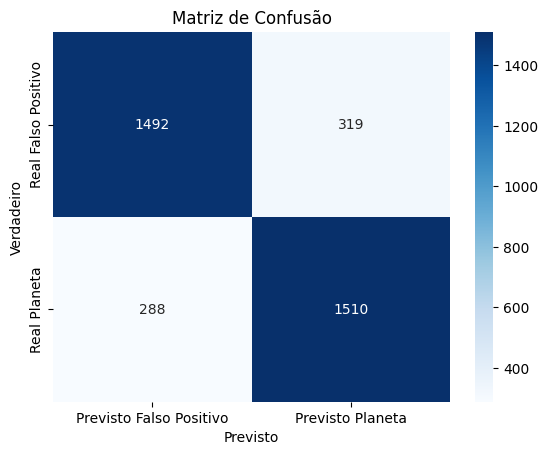

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Iniciando o processo de treinamento e avaliação...")

# --- Passo 1: Separar Features (X) e Alvo (y) ---
# Features são todas as colunas, exceto 'target' e 'source'
features = [
    'orbital_period',
    'transit_duration_hr',
    'transit_depth_ppm',
    'planet_radius_earth',
    'stellar_temp_k',
    'stellar_radius_solar',
    'stellar_mass_solar', 
    'impact_parameter', 
    'equilibrium_temp',
    # NOSSAS NOVAS FEATURES:
    'stellar_density', 
    'duration_over_period', 
    'depth_per_planet_radius'   
]
X = df_featured[features]
y = df_featured['target']

# --- Passo 2: Lidar com quaisquer valores ausentes restantes ---
# Preenchemos NaNs com 0, uma abordagem segura para modelos baseados em árvores
X = X.fillna(0)

# --- Passo 3: Dividir os dados em conjuntos de Treino e Teste ---
# Usamos stratify=y para garantir que a proporção de planetas/não-planetas seja a mesma
# nos conjuntos de treino e teste, o que é crucial para uma avaliação justa.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,       # 30% dos dados para teste, 70% para treino
    random_state=42,     # Garante que a divisão seja sempre a mesma ao rodar o código
    stratify=y
)
print(f"Dados divididos: {X_train.shape[0]} para treino, {X_test.shape[0]} para teste.")


# --- Passo 4: Treinar o Modelo XGBoost ---
# Instanciamos o classificador com parâmetros padrão recomendados
model = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='logloss',
    random_state=42
)

print("💪 Treinando o modelo... Isso pode levar alguns segundos.")
model.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")


# --- Passo 5: Avaliar o Modelo no Conjunto de Teste ---
print("\n--- Resultados da Avaliação no Conjunto de Teste ---")
# O modelo "vê" o X_test e tenta prever o y_test
y_pred = model.predict(X_test)

# Acurácia: a porcentagem geral de acertos
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")

# Relatório de Classificação: mostra precisão, recall e f1-score para cada classe
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Falso Positivo (0)', 'Planeta (1)']))

# Matriz de Confusão: uma forma visual de ver os acertos e erros
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Previsto Falso Positivo', 'Previsto Planeta'], 
            yticklabels=['Real Falso Positivo', 'Real Planeta'])
plt.title('Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()